# SQL 高度活用:Window関数　+ ETL連携

## 目的
- SQL のWindow関数で移動平均を計算する
- SQL　でクロスオーバーシグナル（売買シグナル）を作成する
- SQLの結果をPythonに渡して統計検定を実施する
- SQL→Python→分析　のETL的なデータフローを実演する

## Window関数とは
通常の GROUP BY は　グループごとに1行に集約する
Window関数は 集約せずに、各行に計算結果を追加　できる

例: GROUP BYで月平均を出すと月ごとに1行になる。
Window関数なら「各日に、その日までの20日間の平均」を追加できる。
→移動平均の計算に最適。

In [1]:
#ライブラリのインポート
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14,7)
sns.set_style('whitegrid')

#データベース接続
conn = sqlite3.connect('nikkei225.db')

#データ確認
count = pd.read_sql("SELECT COUNT(*) as cnt FROM raw_nikkei225", conn)
print(f"✓　データベース接続完了: {count['cnt'][0]}行のデータ")

✓　データベース接続完了: 1766行のデータ


## 1. Window関数で移動平均を計算

### GROUP BY vs Window関数の違い

  GROUP BY
  '''sql
  SELECT month, AVG(close) FROM . . . GROUP BY month
  -- →月ごとに1行（行数が減る）
  '''

Window関数:
'''sql
SELECT date, close, AVG(close) OVER (ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW)
-- → 全行そのまま残る＋各行に移動平均が追加される
'''

'OVER (. . .)' がWindow関数の印。「どの範囲で計算するか’を窓(Window)として指定する
  

In [5]:
# Window関数で移動平均を計算

#　まず既存テーブルがあれば削除(何度でも実行可能にする)
conn.execute("DROP TABLE IF EXISTS with_moving_avg")

conn.execute("""
             CREATE TABLE with_moving_avg AS
             SELECT
                date,
                close,
                ROUND(AVG(close) OVER (
                    ORDER BY date
                    ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
                ), 2) as ma_20,
                ROUND(AVG(close) OVER (
                    ORDER BY date
                    ROWS BETWEEN 199 PRECEDING AND CURRENT ROW
                ), 2) as ma_200
             FROM raw_nikkei225
             ORDER BY date
""")
conn.commit()

#結果確認
result = pd.read_sql("""
                     SELECT date, close, ma_20, ma_200
                     FROM with_moving_avg
                     ORDER BY date DESC
                     LIMIT 10
""", conn)
print("【Window関数で計算した移動平均（最新10日）】")
print(result.to_string(index=False))

total = pd.read_sql("SELECT COUNT(*) as cnt FROM with_moving_avg", conn)
print(f"\n✓ with_moving_avg テーブル作成完了: {total['cnt'][0]}行")

【Window関数で計算した移動平均（最新10日）】
      date        Close    ma_20   ma_200
2026-04-02 52469.820312 53544.53 47857.35
2026-04-01 53739.679688 53633.32 47783.71
2026-03-31 51063.718750 53760.28 47702.78
2026-03-30 51885.851562 54109.96 47636.20
2026-03-27 53373.070312 54458.18 47564.01
2026-03-26 53603.648438 54727.20 47484.50
2026-03-25 53749.621094 54976.17 47406.30
2026-03-24 52252.281250 55154.74 47329.72
2026-03-23 51515.488281 55383.42 47257.07
2026-03-19 53372.531250 55681.03 47188.11

✓ with_moving_avg テーブル作成完了: 1766行


## 2. SQLでクロスオーバーシグナルを生成

Window関数の'LAG()'を使って「前日の値」を参照し、
MA20とMA200のクロス（交差）を検出する。

LAG()とは:
「1行前の値」を取得する関数。
今日のMA２０と昨日のMA２０を比較することで、
「今日初めてMA２０がMA２００を上回った（ゴールデンクロス）」を検出できる。

In [6]:
# LAG案数でクロスオーバーシグナルを検出
signals = pd.read_sql("""
                      SELECT
                        date,
                        close,
                        ma_20,
                        ma_200,
                        CASE
                            WHEN ma_20> ma_200
                                AND LAG(ma_20) OVER (ORDER BY date) <= LAG(ma_200) OVER (ORDER BY date)
                            THEN 'BUY'
                            WHEN ma_20< ma_200
                                AND LAG(ma_20) OVER (ORDER BY date) >= LAG(ma_200) OVER (ORDER BY date)
                            THEN 'SELL'
                            ELSE NULL
                        END as signal
                      FROM with_moving_avg
                      WHERE ma_200 IS NOT NULL
""", conn)

#シグナルがある行だけ抽出
signals_only = signals[signals['signal'].notna()].copy()
print("【SQL で生成したクロスオーバーシグナル】")
print(signals_only.to_string(index=False))
print(f"\n  BUY シグナル:  {(signals_only['signal'] == 'BUY').sum()} 回")
print(f"  SELL シグナル: {(signals_only['signal'] == 'SELL').sum()} 回")


【SQL で生成したクロスオーバーシグナル】
      date        Close    ma_20   ma_200 signal
2019-02-04 20883.769531 20543.00 20496.28    BUY
2019-06-03 20410.880859 21178.01 21237.28   SELL
2019-07-03 21638.160156 21236.55 21226.41    BUY
2019-08-13 20455.439453 21235.56 21246.88   SELL
2019-09-24 22098.839844 21239.12 21215.72    BUY
2020-03-11 19416.060547 22053.53 22158.02   SELL
2020-06-12 22305.480469 21803.14 21749.44    BUY
2021-08-06 27820.039062 27891.58 27927.46   SELL
2021-09-13 30447.369141 28511.77 28455.04    BUY
2021-10-22 28804.849609 28760.68 28803.61   SELL
2021-11-05 29611.570312 28931.95 28875.39    BUY
2021-12-13 28640.490234 28840.85 28877.67   SELL
2022-08-10 27819.330078 27623.21 27550.45    BUY
2022-10-04 26992.210938 27313.77 27330.03   SELL
2022-11-09 27716.429688 27208.25 27152.84    BUY
2022-12-29 26093.669922 27220.13 27258.10   SELL
2023-02-14 27602.769531 27319.27 27250.22    BUY
2024-08-19 37388.621094 36997.51 37051.91   SELL
2024-09-05 36657.089844 37508.59 37464.63    B

## 3. SQLの結果をPythonに渡して統計検定

ここがETL的な思考の実演。
-- E(Extract):　データベースからデータを取得
-- T(Transform): SQLでシグナル生成（加工）
-- L(Load): Python に渡して分析(活用)

SQL「データの加工」に強く、Pythonは「統計分析・可視化」に強い。
それぞれの得意分野を活かして連携させる。

In [9]:
# SQL データからトレードリターンを計算
buy_rows = signals_only[signals_only['signal'] == 'BUY'].reset_index(drop=True)
sell_rows = signals_only[signals_only['signal'] == 'SELL'].reset_index(drop=True)

trades = []
for i, buy in buy_rows.iterrows():
    #この会の後の最初の売りを探す
    future_sells = sell_rows[sell_rows['date'] > buy['date']]
    if len(future_sells) > 0:
        sell = future_sells.iloc[0]
        return_pct = (sell['Close'] - buy['Close']) / buy['Close'] * 100
        trades.append({
            'buy_date': buy['date'],
            'sell_date': sell['date'],
            'buy_price': buy['Close'],
            'sell_price': sell['Close'],
            'return_pct': return_pct
            })
trades_df = pd.DataFrame(trades)

print("【SQL データによるトレード結果】")
print(trades_df.to_string(index=False))
print(f"\n  トレード数: {len(trades_df)}")
print(f"  勝率:       {(trades_df['return_pct'] > 0).mean() * 100:.1f}%")
print(f"  平均リターン: {trades_df['return_pct'].mean():.2f}%")

【SQL データによるトレード結果】
  buy_date  sell_date    buy_price   sell_price  return_pct
2019-02-04 2019-06-03 20883.769531 20410.880859   -2.264384
2019-07-03 2019-08-13 21638.160156 20455.439453   -5.465902
2019-09-24 2020-03-11 22098.839844 19416.060547  -12.139910
2020-06-12 2021-08-06 22305.480469 27820.039062   24.722886
2021-09-13 2021-10-22 30447.369141 28804.849609   -5.394619
2021-11-05 2021-12-13 29611.570312 28640.490234   -3.279394
2022-08-10 2022-10-04 27819.330078 26992.210938   -2.973181
2022-11-09 2022-12-29 27716.429688 26093.669922   -5.854866
2023-02-14 2024-08-19 27602.769531 37388.621094   35.452426
2024-09-05 2024-09-13 36657.089844 36581.761719   -0.205494
2024-10-11 2024-12-06 39605.800781 39091.171875   -1.299378
2024-12-11 2025-03-04 39372.230469 37331.179688   -5.183986

  トレード数: 12
  勝率:       16.7%
  平均リターン: 1.34%


In [10]:
# t検定（SQLデータ版）
returns = trades_df['return_pct'].values

t_stat, p_value = stats.ttest_1samp(returns, 0)

print("=" * 60)
print("【t検定結果】SQL データによる移動平均クロスオーバー戦略")
print("=" * 60)
print(f"  サンプルサイズ: {len(returns)}")
print(f"  平均リターン:   {np.mean(returns):.4f}%")
print(f"  標準偏差:       {np.std(returns, ddof=1):.4f}%")
print(f"  t統計量:        {t_stat:.4f}")
print(f"  p値:            {p_value:.6f}")
print("=" * 60)

if p_value < 0.05:
    print(f"\n✓ p値 = {p_value:.4f} < 0.05 → 統計的に有意")
else:
    print(f"\n✗ p値 = {p_value:.4f} >= 0.05 → 統計的に有意ではない")

【t検定結果】SQL データによる移動平均クロスオーバー戦略
  サンプルサイズ: 12
  平均リターン:   1.3428%
  標準偏差:       13.9493%
  t統計量:        0.3335
  p値:            0.745045

✗ p値 = 0.7450 >= 0.05 → 統計的に有意ではない


## 4.日次リターンの分析(SQL+Python)
SQLで日次リターンを計算し、Pythonで分析を可視化する。

In [11]:
# SQLで日次リターンを計算
daily_returns= pd.read_sql("""
                           SELECT
                            date,
                            Close,
                            LAG(Close) OVER (ORDER BY date) as prev_close,
                            ROUND(
                                (Close - LAG(Close) OVER (ORDER BY date))
                                /LAG(Close) OVER (ORDER BY date) * 100,
                            4
                           ) as daily_return
                        FROM raw_nikkei225
                        ORDER BY date
""", conn)

#欠損値を除去（最初の1行はLAGで前日がないためNULL)
daily_returns = daily_returns.dropna()

print("【SQL で計算した日次リターン（最新10日）】")
print(daily_returns.tail(10).to_string(index=False))
print(f"\n  全営業日数: {len(daily_returns)}")
print(f"  平均日次リターン: {daily_returns['daily_return'].mean():.4f}%")
print(f"  標準偏差: {daily_returns['daily_return'].std():.4f}%")

【SQL で計算した日次リターン（最新10日）】
      date        Close   prev_close  daily_return
2026-03-19 53372.531250 55239.398438       -3.3796
2026-03-23 51515.488281 53372.531250       -3.4794
2026-03-24 52252.281250 51515.488281        1.4302
2026-03-25 53749.621094 52252.281250        2.8656
2026-03-26 53603.648438 53749.621094       -0.2716
2026-03-27 53373.070312 53603.648438       -0.4302
2026-03-30 51885.851562 53373.070312       -2.7865
2026-03-31 51063.718750 51885.851562       -1.5845
2026-04-01 53739.679688 51063.718750        5.2404
2026-04-02 52469.820312 53739.679688       -2.3630

  全営業日数: 1765
  平均日次リターン: 0.0652%
  標準偏差: 1.3601%


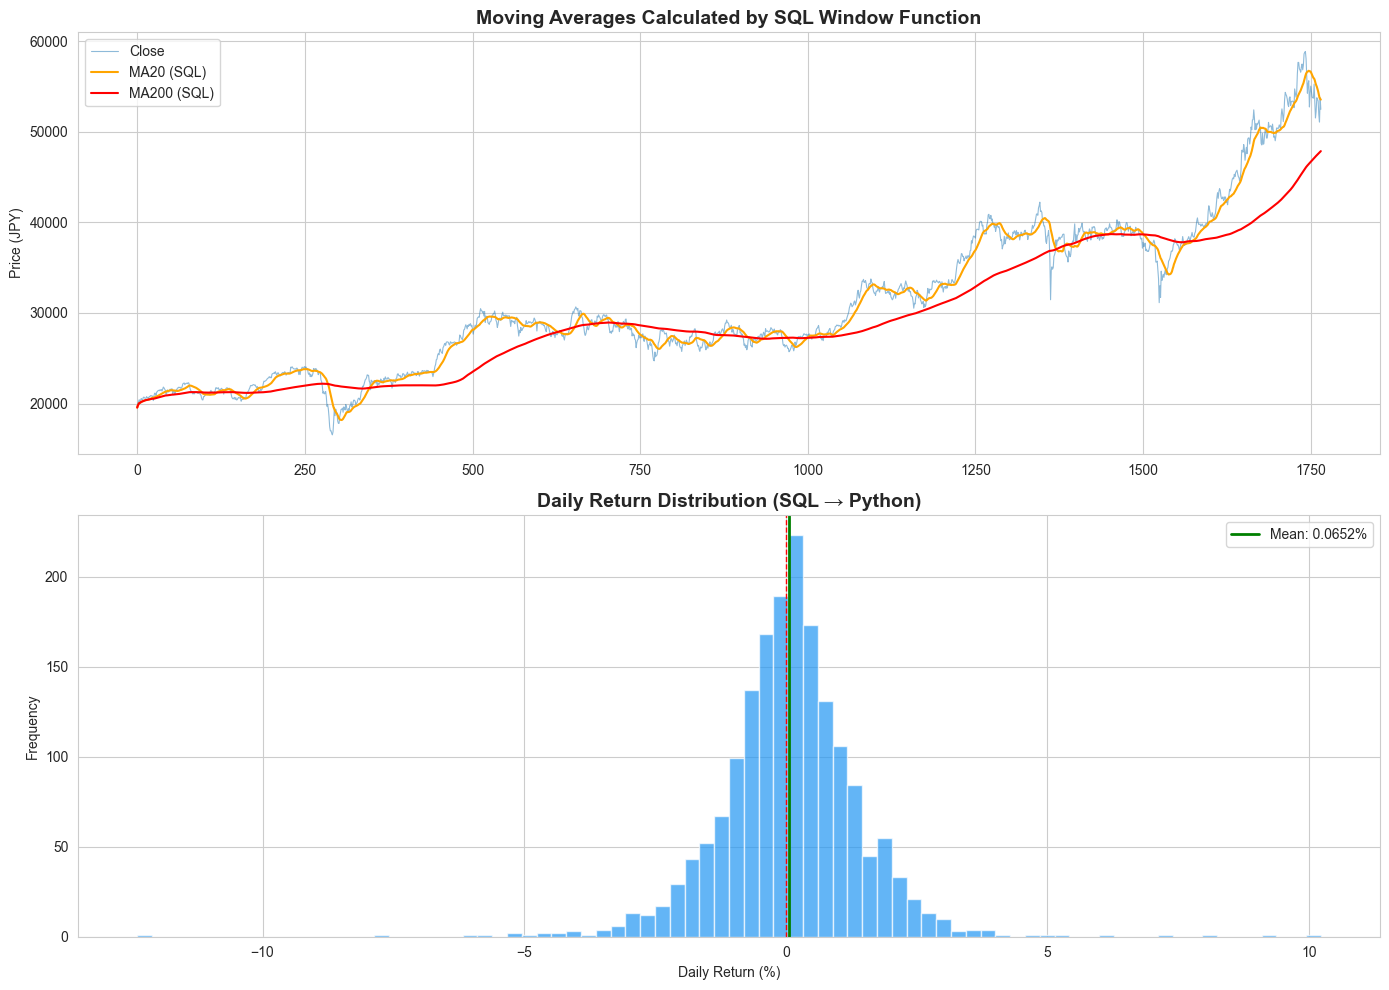

✓ SQL高度分析グラフ保存完了


In [13]:
# ===== 可視化：日次リターンの分布 + SQL移動平均 =====
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 上段：移動平均（SQLデータ）
ma_data = pd.read_sql("""
    SELECT date, close, ma_20, ma_200 
    FROM with_moving_avg 
    WHERE ma_200 IS NOT NULL
    ORDER BY date
""", conn)

axes[0].plot(range(len(ma_data)), ma_data['Close'], alpha=0.5, linewidth=0.8, label='Close')
axes[0].plot(range(len(ma_data)), ma_data['ma_20'], color='orange', linewidth=1.5, label='MA20 (SQL)')
axes[0].plot(range(len(ma_data)), ma_data['ma_200'], color='red', linewidth=1.5, label='MA200 (SQL)')
axes[0].set_title('Moving Averages Calculated by SQL Window Function', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (JPY)')
axes[0].legend(loc='upper left')

# 下段：日次リターン分布
axes[1].hist(daily_returns['daily_return'], bins=80, color='#2196F3', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].axvline(x=daily_returns['daily_return'].mean(), color='green', linestyle='-', linewidth=2,
                label=f'Mean: {daily_returns["daily_return"].mean():.4f}%')
axes[1].set_title('Daily Return Distribution (SQL → Python)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('sql_advanced_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ SQL高度分析グラフ保存完了")

In [14]:
#データベース接続を閉じる
conn.close()
print("✓ データベース接続を閉じました")

✓ データベース接続を閉じました


## 5. まとめ

Window関数 は GROUP BY と異なり、行を集約せずに新しいカラムを横に追加する。
GROUP BY は「月ごとに1行にまとめる」ので行数が減るが、
Window関数は全行をそのまま残したまま「各行に、その行を含む直近20日間の平均」を追加できる。
データ規模が大きくなっても効率的に処理できる点でスケーラビリティに優れている。

LAG関数 は「指定した行数だけ前の値」を参照できる Window関数の一種。
今日と昨日の値を比較することで、移動平均線の交差（クロスオーバー）を検出できる。

SQL と Python の使い分け： SQL はデータの抽出・加工に強く、何千万行あっても
データベース内で高速に処理できる。Python は統計分析や可視化に強い。
実務では「SQL で加工 → Python で分析・可視化」という連携が基本パターン。


### 出力結果について

Window関数を用いて終値の横に MA20・MA200 を計算し、移動平均分析の準備を行った。
続いて SQL の LAG関数でクロスオーバーシグナルを検出し、BUY 13回・SELL 12回を確認。

トレード結果は12件完了、勝率16.7%、平均リターン+1.34%。
勝率は低いが、2件の大勝ち（+24.7%、+35.5%）が多数の小さな損失をカバーしている構図。

t検定結果：p値 = 0.745 → 統計的に有意ではない。
t統計量 0.33 は「平均が0からほとんど離れていない」ことを意味する
（一般に2以上ないと有意になりにくい）。
平均リターン+1.34% は一見プラスだが、標準偏差が約14%と非常に大きい。
平均に対してバラつきが10倍あるので、「たまたまプラスになっただけ」と
「本当にプラスの実力がある」の区別がつかない。
この戦略が実行可能であるという統計的な裏付けは得られなかった。

全営業日の平均日次リターン（0.065%）と比較すると、
この戦略の1トレードあたりのリターン（1.34%）は大きく見えるが、
保有期間が平均数十〜数百日あるため、日数で割ると日次リターンと大差ない。
日次リターンの標準偏差（1.36%）の方がトレードリターン（14%）よりはるかに小さいが、
これは「1日の変動」と「数ヶ月の変動」を比べているため当然の結果。